# Probabilistic Model Using VED
The objective of this workflow is to establish a probabilistic link between additive manufacturing process parameters and fatigue life.

This model uses **synthetic defect data from the VED**: many specimens, each with a varying number of different defects, are generated. The largest defect is taken as the critical defect from which the fatigue life is predicted.

The workflow follows:
**Process Parameters → VED → Defect Population → a_max → ΔK_i →Nf**

This creates a framework capable of quantifying both expected fatigue life and uncertainty.

# Imports

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import lognorm, weibull_min, genextreme, kstest
from dataclasses import dataclass
import random
import torch
import torch.nn as nn

# 1. Input Parameters
collects all fixed inputs (material, geometry, loading, AM process)

## 1.1. Material Parameters
Paris law constants, fracture toughness, threshold SIF

Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

In [96]:
C = 0.76899e-7     # Paris constant [m/cycle / (MPa√m)^m]
m = 2.56492        # Paris exponent    [–]

print(f"Paris law: da/dN = {C:.2e} * deltaK^{m}")

Paris law: da/dN = 7.69e-08 * deltaK^2.56492


*For Paris constants, C and m:*
Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. SSRN Electronic Journal, 2022. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

## 1.2. Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [97]:
# w = 5e-3        # cross-section width [m]
# h_s = 5e-3      # cross-section height [m]
# L = 20e-3       # gauge length [m]

# specimen dimensions: assume cylinderical gauge section, A = π * (d/2)^2
h = 10e-3               # height [m]
d = 5e-3                # diameter [m]
A = np.pi * (d/2)**2    # cross-sectional area [m^2]

V_gauge = A * h                # gauge volume [m^3]
V_gauge_mm3 = V_gauge * 1e9    # [mm^3] for display

# Geometry correction factor Y (Murakami framework)
#   Y = 0.5 for internal defect
#   Y = 0.65 for surface defect
defect_location = "internal"
Y = 0.5 if defect_location == "internal" else 0.65

print(f"Gauge volume V = {V_gauge_mm3:.1f} mm^3")
print(f"Defect location: {defect_location} → Y = {Y}")

Gauge volume V = 196.3 mm^3
Defect location: internal → Y = 0.5


## 1.3. Loading Parameters
stress amplitude, mean stress, frequency

In [98]:
sigma_a = 500.0     # stress amplitude [MPa]
sigma_m = 0.0       # mean stress [MPa]  (0 → fully reversed, R = -1)
freq = 110.0        # cyclic frequency [Hz]

sigma_max = sigma_m + sigma_a
sigma_min = sigma_m - sigma_a
R = sigma_min / sigma_max if sigma_max != 0 else float("nan")

# Effective stress range:
    # crack faces close under compression, no damage contribution
delta_sigma = sigma_max - max(sigma_min, 0.0)   # deltaK = Y*delta_sigma*√(pi*a)

print(f"sigma_a = {sigma_a} MPa, sigma_m = {sigma_m} MPa")
print(f"sigma_max = {sigma_max:.1f}, sigma_min = {sigma_min:.1f}, R = {R:.2f}")
print(f"Effective delta_sigma = {delta_sigma:.1f} MPa")

sigma_a = 500.0 MPa, sigma_m = 0.0 MPa
sigma_max = 500.0, sigma_min = -500.0, R = -1.00
Effective delta_sigma = 500.0 MPa


*For stress and frequency values:*
Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. SSRN Electronic Journal, 2022. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

## 1.4. Process Params & VED
laser power, scan speed, hatch spacing, layer thickness

The Volumetric Energy Density (VED) is the laser energy input per unit volume of material:

**VED = P / (vht)**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

and
- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

Here, VED is a **process input** that controls defect statistics.

In [99]:
# define process parameters
P = 280.0     # laser power [W]
v = 1200.0    # scan speed [mm/s]
h = 0.140     # hatch spacing [mm]
t = 0.03      # layer thickness [mm]

# volumetric energy density
VED_op = P / (v * h * t)

print(f"P = {P} W,  v = {v} mm/s,  h = {h} mm,  t = {t} mm")
print(f"VED_op = {VED_op:.2f} J/mm^3")

P = 280.0 W,  v = 1200.0 mm/s,  h = 0.14 mm,  t = 0.03 mm
VED_op = 55.56 J/mm^3


*For energy densities and parameters:*
Sola, A., Nouri, A., Peyre, P., Ghodbane, J., Sanz, C., Morville, S., Hueso, J., & Aubry, P. (2021). Processability of pure copper by laser powder bed fusion and its potential applications. Additive Manufacturing, 47, 102340. <https://www.sciencedirect.com/science/article/pii/S2214860420309246#tbl0005>. 

*More data:*
van der Linde, C., Sideris, I., Deillon, L., Afrasiabi, M., & Bambach, M. (2026). Microstructure engineering of Ti-6Al-4V in laser powder bed fusion via 1D thermal modeling and supporting experiments. arXiv:2604.24669.
https://arxiv.org/html/2604.24669v1 

# 2. Volume, Relative Density, and PDF
Process parameters determine the volumetric energy density (VED), which influences defect formation. Defect populations then determine the size of the largest critical defect in each specimen. Through fracture mechanics and the Paris law, the critical defect size controls the fatigue life.

This section will present the following:
- Volumetric Energy Density (VED) from AM process parameters
- Relative density from XCT data
- Expected defect count in the gauge volume
- Parametric PDF fit to measured defect sizes

## 2.1. VED & Densities

### 2.1.a. VED-Relative Density Correlation
A **simplified empirical approximation** curve relates VED to relative density. This relationship should be treated as illustrative.

*For relative densities and optimal VED values:*
Bittner, F., Müller, B., & Thielsch, J. (2022). Efficient LPBF-process development by Design of Experiments. Fraunhofer Institute for Machine Tools and Forming Technology (IWU), Dresden, Germany. <https://publica-rest.fraunhofer.de/server/api/core/bitstreams/5db78b1a-ed75-4d57-aa78-b5712aae8a45/content>. 

*For relative density values and expected relative density vs. VED curve:*
Park, H. et al. (2024). Relationship between volumetric energy density and relative density in laser powder bed fusion additive manufacturing: A review and analysis. Journal of Powder Materials, 2024. <https://www.powdermat.org/journal/view.php?doi=10.4150/jpm.2024.00038>.

In [100]:
# define VED-relative density relationship parameters
VED_opt = 81.0        # optimal VED

rd_min = 0.865        # min relative density (normalized to 1 at optimal VED)
rd_max = 0.99992      # max relative density (normalized to 1 at optimal VED)

k = 0.05              # steepness of VED curve

In [101]:
# define function to calculate relative density 
def rel_density(VED):
    rel_d = rd_max - (rd_max - rd_min) * np.exp(-k * VED)

    return rel_d

rel_d_op = rel_density(VED_op)          # relative density at operating VED
rel_d_opt = rel_density(VED_opt)        # relative density at optimal VED

print(f"Relative density at operating VED ({VED_op} J/mm^3) = {rel_d_op:.4f}")
print(f"Relative density at optimal VED ({VED_opt} J/mm^3) = {rel_d_opt:.4f}")

Relative density at operating VED (55.55555555555554 J/mm^3) = 0.9915
Relative density at optimal VED (81.0 J/mm^3) = 0.9976


In [102]:
VED_sweep = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]  # VED range for sweep [J/mm^3]

rel_d_sweep = []       # list to store relative density values for each VED

for VED_i in VED_sweep:
    rel_d = rel_density(VED_i)
    rel_d_sweep.append(rel_d)

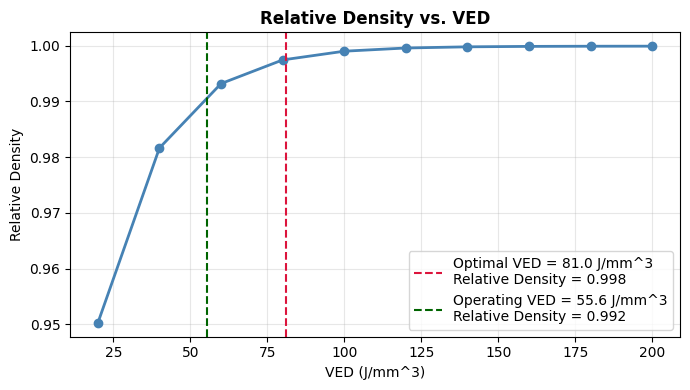

In [103]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(VED_sweep, rel_d_sweep, marker='o', color="steelblue", linewidth=2)

# add line indicating operating defect density
ax.axvline(VED_opt, color="crimson", 
           linestyle="--", linewidth=1.5,
           label=f"Optimal VED = {VED_opt:.1f} J/mm^3\nRelative Density = {rel_d_opt:.3f}")

# add line indicating operating defect density
ax.axvline(VED_op, color="darkgreen",
           linestyle="--", linewidth=1.5,
           label=f"Operating VED = {VED_op:.1f} J/mm^3\nRelative Density = {rel_d_op:.3f}")

# axes labels, title, legend, grid
ax.set_title("Relative Density vs. VED", fontweight="bold")
ax.set_xlabel("VED (J/mm^3)")
ax.set_ylabel("Relative Density")

# legend, grid
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/2_VED_reld.png", dpi=150)
plt.show()

### 2.1.b. VED-Defect Density Correlation
An **empirical quadratic model** for defect density as a function of VED is derived from a simple vertex form of a parabola, with a minimum at the optimal VED.

In [104]:
# define VED-defect density relationship parameters
rho_opt = 20.0        # min defect density at optimal VED [defects/mm^3]
# rho_max = 300.0       # max defect density at optimal VED [defects/mm^3]

alpha = 5e-6          # sensitivity of defect density to VED deviations
std_dev = 5.0         # std dev (width parameter) of Gaussian curve

In [105]:
# define a function to calculate the defect density as a function of VED
def defect_density(VED):
    # empirical quadratic model, Taylor expansion, y = a(x-h)^2 + k
    rho = alpha * (VED - VED_opt)**2 + rho_opt

    return rho

rho_op = defect_density(VED_op)    # defect density at operating VED

print(f"Defect density at operating VED ({VED_op} J/mm^3) = {rho_op:.1f} defects/mm^3")
print(f"Defect density at optimal VED ({VED_opt} J/mm^3) = {rho_opt:.1f} defects/mm^3")

Defect density at operating VED (55.55555555555554 J/mm^3) = 20.0 defects/mm^3
Defect density at optimal VED (81.0 J/mm^3) = 20.0 defects/mm^3


In [106]:
VED_sweep = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]  # VED range for sweep [J/mm^3]

rho_sweep = []       # list to store defect density values for each VED

for VED_i in VED_sweep:
    rho = defect_density(VED_i)
    rho_sweep.append(rho)

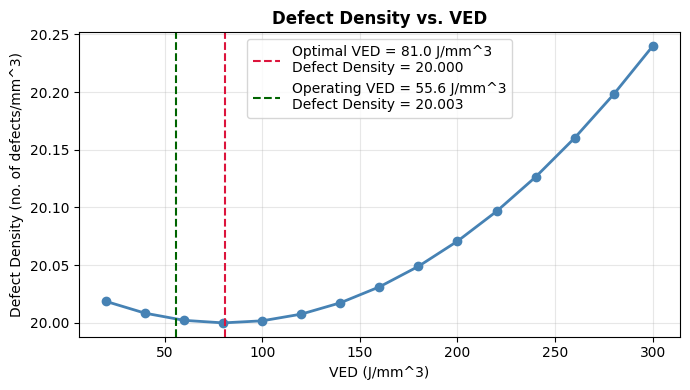

In [107]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(VED_sweep, rho_sweep, marker='o', color="steelblue", linewidth=2)

# add line indicating optimal defect density
ax.axvline(VED_opt, color="crimson", 
           linestyle="--", linewidth=1.5,
           label=f"Optimal VED = {VED_opt:.1f} J/mm^3\nDefect Density = {rho_opt:.3f}")

# add line indicating operating defect density
ax.axvline(VED_op, color="darkgreen",
           linestyle="--", linewidth=1.5,
           label=f"Operating VED = {VED_op:.1f} J/mm^3\nDefect Density = {rho_op:.3f}")

# axes labels, title, legend, grid
ax.set_title("Defect Density vs. VED", fontweight="bold")
ax.set_xlabel("VED (J/mm^3)")
ax.set_ylabel("Defect Density (no. of defects/mm^3)")

# legend, grid
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/2_VED_rho.png", dpi=150)
plt.show()

## 2.2. Synthetic Defect Population
Generate a synthetic defect population (many specimens, each with many defects) from the VED.

### 2.2.a. Defect Size Distribution Parameters
Connect process parameters (VED) to defect-size population with **empirical statistical models**.

Assume defect size follows a **lognormal distribution** because defect growth results from *multiple multiplicative manufacturing effects* such as powder size variation, melt-pool instability, lack-of-fusion events, and gas entrapment. The lognormal distribution is widely used in additive manufacturing defect characterization because it:
- guarantees positive defect sizes,
- reproduces the right-skewed distributions commonly observed in XCT measurements,
- naturally accommodates rare large defects,
- is straightforward to sample in Monte Carlo simulations.

First, the defect size distribution parameters—**mean, standard deviation**—are calculated from the VED.

In [108]:
# define functions to calculate defect size distribution parameters from VED

# mean of ln(defect size)
def defect_mu(VED, VED_opt):
    mu_0 = np.log(50e-6)        # assume exp(mu_ln) = 50 micrometers at VED_opt
    beta = 2e-6                 # sensitivity to VED deviation  [ln(m) / (J/mm^3)^2]
    
    mu_ln = mu_0 + beta * (VED - VED_opt)**2
    return mu_ln

# std dev of ln(defect size) as a function of VED
def defect_sigma(VED, VED_opt):
    sigma_0 = 0.35              # minimum log-scatter at optimal VED
    gamma = 1e-5                # scatter sensitivity to VED deviation

    sigma_ln = sigma_0 + gamma * (VED - VED_opt)**2
    return sigma_ln

mu_ln = defect_mu(VED_op, VED_opt)         # mean of log, ~3-6
sigma_ln = defect_sigma(VED_op, VED_opt)   # std dev of log, ~0.2-1

print(f"Defect size lognormal parameters at VED = {VED_op:.1f} J/mm^3:")
print(f"  mu_ln = {mu_ln:.4f} → median defect = {np.exp(mu_ln)*1e6:.1f} micrometers")
print(f"  sigma_ln = {sigma_ln:.4f}")

Defect size lognormal parameters at VED = 55.6 J/mm^3:
  mu_ln = -9.9022 → median defect = 50.1 micrometers
  sigma_ln = 0.3565


### 2.2.b. Porosity & Exp. No. of Defects
Because relative density gives the total missing material volume but not the number of pores, an additional assumption is required: the average pore volume, ⟨V_pore⟩. The expected number of defects in the gauge volume is then estimated as

**⟨N⟩ = (ϕ * V_gauge) / ⟨V_pore⟩**

where the pore volume fraction is **ϕ = 1 − relative density**.

This converts a density/porosity-based process model into a specimen-level defect-count model. 

In [109]:
# # calculate density from relative density
# por = 1.0 - rel_d_op                # porosity = 1 - relative density

# #V_gauge_mm3 = 5 * 5 * 20  # mm^3, example specimen volume

# mean_pore_diameter_mm = 0.05        # 50 micrometers = 0.05 mm
# mean_pore_radius_mm = mean_pore_diameter_mm / 2
# mean_pore_volume_mm3 = (4/3) * np.pi * mean_pore_radius_mm**3

# # calculate expected number of defects
# n_expected = por * V_gauge_mm3 / mean_pore_volume_mm3

# calculate expected number of defects directly from defect density
n_expected = rho_op * V_gauge_mm3  # round to nearest integer

print("Expected number of defects =", n_expected, "defects")

Expected number of defects = 3927.6264198435183 defects


### 2.2.c. Generate Synthetic Population
A synthetic population of specimens is generated: a **random number of defects** is generated in every specimen based on a Poisson distribution, and then **random defect sizes** are generated based on a lognormal distribution.

The number of defects present in each specimen is modeled using a **Poisson distribution**, a common assumption made when defects occur *independently* and *randomly* throughout a volume. The Poisson model *naturally introduces variability* from specimen to specimen. Even if all specimens are manufactured under identical process parameters, some specimens will contain fewer defects than average, while others will contain more. This variability contributes directly to fatigue-life scatter.

In [110]:
rng = np.random.default_rng(seed=42)

# # define function to generate sizes of defects inside each specimen 
# # based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return rng.lognormal(mu,           # mean of logarithm 
                         sigma,        # std dev
                         n_defects)    # no. of random samples generated

In [111]:
# generate a random number of varying defects
# combine n_local and specimen_defects
n_specimens = random.randint(2, 1000)

all_specimens = []              # empty list to store info on all specimens

for i in range(n_specimens):

    # random number of defects in one specimen
    n_local = rng.poisson(n_expected)
    n_local = max(n_local, 1)

    # random defect sizes
    defects = generate_defects(n_local, mu_ln, sigma_ln)

    all_specimens.append(defects)

## 2.3. Fit Parametric PDF
Three candidate distributions are fitted by MLE.

The best distribution is selected by the lowest Kolmogorov–Smirnov statistic.

In [112]:
# convert a list of sequences into a single array
all_specs_array = np.concatenate(all_specimens).astype(float)

In [113]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [114]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(all_specs_array, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name} (KS = {best_ks:.4f}, p = {best_p:.4f})")

param_str = ", ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.0003      0.9541
Weibull               0.0605      0.0000
Gumbel                0.0046      0.0000

Best fit: lognormal (KS = 0.0003, p = 0.9541)
Parameters: mu_ln = -9.902, sigma_ln = 0.3564


### 2.3.a. Defect Size Histogram & PDF

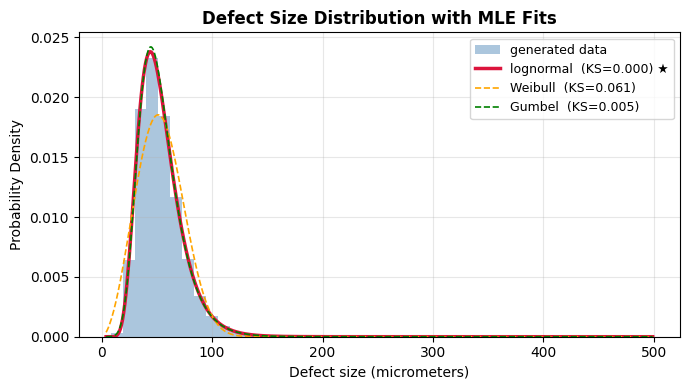

In [115]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = all_specs_array * 1e6   # convert to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(all_specs_array.min() * 0.5, all_specs_array.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution with MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_defect_pdf.png", dpi=150)
plt.show()

## 2.4. Max.-Defect Distribution
Each specimen contains many defects.

Fatigue failure is controlled by the **largest** defect (Murakami).

Instead of taking all the defects from every specimen, only the critical (max.) defect will be chosen for further analysis.

The distribution of per-specimen maxima follows a Generalized Extreme Value (GEV) distribution.

In [116]:
max_defects = []        # empty list to store every max. defect
sqrt_A = []             # empty list to store every sqrt_A

# find the max defect in each specimen
max_defects = np.array([
    np.max(defects)
    for defects in all_specimens
])

# take the square root of every element in the max_defects list
sqrt_A = np.sqrt(max_defects)

# convert arrays for plotting
sqrt_A = np.asarray(sqrt_A, dtype=float)
sqrt_A = sqrt_A[np.isfinite(sqrt_A)]

### 2.4.a. Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

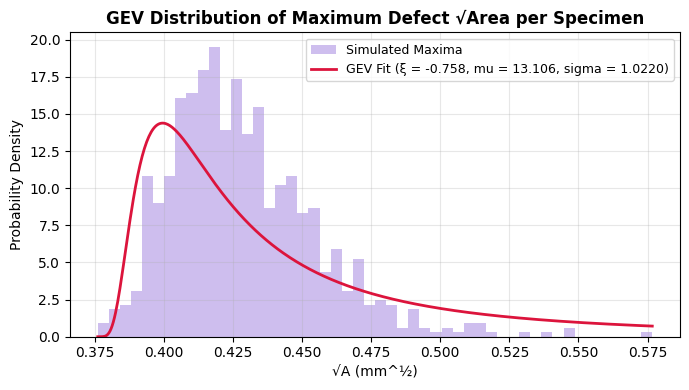

In [117]:
# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(sqrt_A)

x_gev = np.linspace(sqrt_A.min(), sqrt_A.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, gev_loc, gev_scale)

# convert [sqrt(m)] to [sqrt(mm)]
conv = np.sqrt(1000)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sqrt_A * conv,
        bins=50,
        density=True,
        alpha=0.45,
        color="mediumpurple",
        label="Simulated Maxima")

ax.plot(x_gev * conv,
        pdf_gev / conv,
        color="crimson",
        linewidth=2,
        label=f"GEV Fit (ξ = {gev_c:.3f}, mu = {gev_loc*1e3:.3f}, sigma = {gev_scale*1e3:.4f})")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect √Area per Specimen", fontweight="bold")
ax.set_xlabel("√A (mm^½)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_GEV.png", dpi=150)
plt.show()

## 2.5. Paris-Law Fatigue Life Formulas
Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [118]:
# define function based on Paris law
def fatigue_life_paris(a_i, sigma_a, C, m, Y, delta_sigma=None):

    # fully reversed (R = -1)
    if delta_sigma is None:
        delta_sigma = 2.0 * sigma_a
    
    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * np.pi**(m/2))

    Nf = paris_coeff * a_i**(1.0-(m/2.0))
    return Nf

def fatigue_life_paris_torch(a0, sigma_a, C, m, Y, delta_sigma=None):

    # fully reversed loading, R = -1
    if delta_sigma is None:
        delta_sigma = 2.0 * sigma_a

    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * torch.pi**(m / 2.0))

    Nf = paris_coeff * a0**(1.0 - (m / 2.0))
    return Nf

The **stress intensity factor, delta(K)**, the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [119]:
# define function to compute stress intensity factor, deltaK
def stress_intensity_factor(stress_amp, defect_size):
    deltaK = Y * stress_amp * np.sqrt(np.pi * defect_size)
    return deltaK

def stress_intensity_factor_torch(stress_amp, defect_size):
    deltaK = Y * stress_amp * torch.sqrt(torch.pi * defect_size)
    return deltaK

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(a_i, delta_sigma, Y):
    deltaK_i = Y * delta_sigma * np.sqrt(np.pi * a_i)   # [MPa√m]
    return deltaK_i

## 2.6. Fatigue Life Dist. at Fixed Stress
Paris law & Shiozawa give N_f for each specimen.

The resulting distribution captures the scatter from defect variability alone.

In [120]:
S_fixed = sigma_a   # stress amplitude [MPa]

# empty lists to store info
Nf_samples = []
dKi_samples = []
Nnorm_samples = []

# compute fatigue life, deltaK_i, and Murakami √area for each specimen
for a0 in max_defects:
    Nf = fatigue_life_paris(a0, S_fixed, C, m, Y, delta_sigma=delta_sigma)
    dKi = delta_K_initial(a0, delta_sigma, Y)
    Nnorm = Nf / np.sqrt(a0)        # normalized life, N/√A

    Nf_samples.append(Nf)
    dKi_samples.append(dKi)
    Nnorm_samples.append(Nnorm)

In [121]:
# convert all Monte Carlo result lists to arrays
max_defects = np.asarray(max_defects, dtype=float)
Nf_samples = np.asarray(Nf_samples, dtype=float)
dKi_samples = np.asarray(dKi_samples, dtype=float)
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

# create one shared mask for valid rows (positive finite fatigue lives)
valid_mc = (
    np.isfinite(max_defects) &
    np.isfinite(Nf_samples) & (Nf_samples > 0) &
    np.isfinite(dKi_samples) & (dKi_samples > 0) &
    np.isfinite(Nnorm_samples) & (Nnorm_samples > 0)
)

# apply the same mask to everything
max_defects_valid = max_defects[valid_mc]
Nf_samples_valid = Nf_samples[valid_mc]
dKi_samples_valid = dKi_samples[valid_mc]
Nnorm_samples_valid = Nnorm_samples[valid_mc]

### 2.6.a Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:
(N/√A) ∝ (deltaK_i)^(-m)
log(deltaK_i) = -(1/m)*log(N/√A) + C
→ **slope = -1/m**

In [122]:
# log-log linear fit
log_Nnorm = np.log10(Nnorm_samples_valid).flatten()
log_dKi = np.log10(dKi_samples_valid).flatten()

In [123]:
# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = -1.0 / m

print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# convert to numpy arrays
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

N_norm_line = np.logspace(
    np.log10(Nnorm_samples.min()),
    np.log10(Nnorm_samples.max()),
    300
)
dK_line = a_fit * N_norm_line**slope

Shiozawa log-log fit: slope = -0.6390
Expected from Paris (m=2.56492): slope = -0.3899


In [124]:
# confidence intervals for the fit line

# create bins for logNnorm
bins_Nnorm = np.linspace(min(log_Nnorm), max(log_Nnorm), 20)

# calculate mean and std dev of stress values in each bin
log_dKi_avg = []
log_dKi_std = []
centers = []

for i in range(len(bins_Nnorm) - 1):
    mask = (log_Nnorm >= bins_Nnorm[i]) & (log_Nnorm < bins_Nnorm[i+1])
    Ks_in_bin = np.array(log_dKi)[mask]

    if Ks_in_bin.size == 0:
        continue
    
    log_dKi_avg.append(np.mean(Ks_in_bin))
    log_dKi_std.append(np.std(Ks_in_bin))
    centers.append(0.5 * (bins_Nnorm[i] + bins_Nnorm[i+1]))

log_dKi_avg = np.array(log_dKi_avg)
log_dKi_std = np.array(log_dKi_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper_K = log_dKi_avg + 1.96 * log_dKi_std
lower_K = log_dKi_avg - 1.96 * log_dKi_std

# convert log-space CI back to real ΔK values
upper_dK = 10**upper_K
lower_dK = 10**lower_K
xvals1 = 10**centers

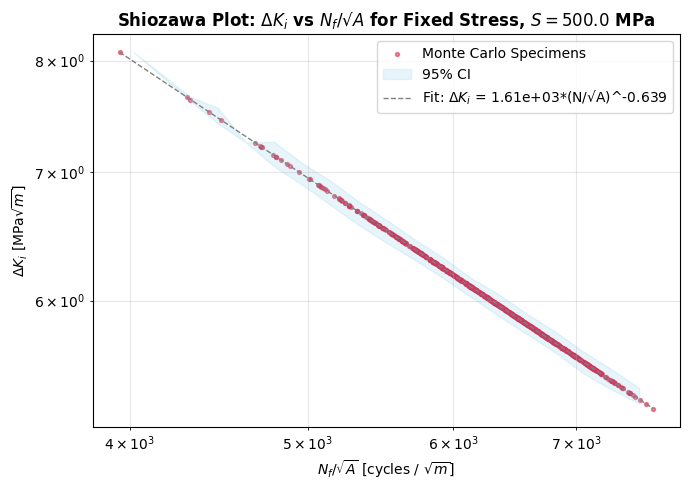

In [125]:
# plot Shiozawa plot
fig, ax = plt.subplots(figsize=(7, 5))

# show Monte Carlo specimens as scatter points
ax.scatter(Nnorm_samples, dKi_samples, alpha=0.5, s=8, color="crimson",
           label="Monte Carlo Specimens")

# show confidence intervals as shaded area
plt.fill_between(xvals1, lower_dK, upper_dK,
                 color='skyblue',
                 alpha=0.2,
                 label='95% CI')

# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="grey", linewidth=1, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}*(N/√A)^{slope:.3f}")

# log-log scale for Shiozawa plot
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_title(f"Shiozawa Plot: $\\Delta K_i$ vs $N_f / √A$ for Fixed Stress, $S = {S_fixed}$ MPa",
             fontweight="bold")
ax.set_xlabel("$N_f / \\sqrt{A}$ [cycles / $\\sqrt{m}$]")
ax.set_ylabel("$\\Delta K_i$ [MPa$\\sqrt{m}$]")

# legend, grid
ax.legend()
ax.grid(alpha=0.3, which="both")

# save and show
plt.tight_layout()
plt.savefig("graphs/2_shiozawa.png", dpi=150)
plt.show()

### 2.6.b Reliability Curves: Empirical & Weibull Model

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

Weibull: β = 35.688, η = 8.657e+01
  B10 (10% failure) = 8.128e+01 cycles
  B50 (50% failure) = 8.569e+01 cycles


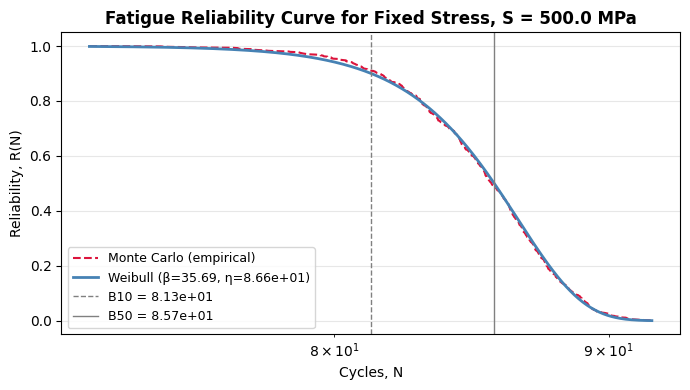

In [126]:
lives_sorted = np.sort(Nf_samples_valid)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_samples, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Monte Carlo (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")
# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Fatigue Reliability Curve for Fixed Stress, S = {S_fixed} MPa",
             fontweight="bold")
ax.set_xlabel("Cycles, N")
ax.set_ylabel("Reliability, R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_reliability.png", dpi=150)
plt.show()

## 2.7. Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

Shiozawa collapse fit: slope = -0.3910
Expected from Paris (m=2.56492): slope = -0.3899


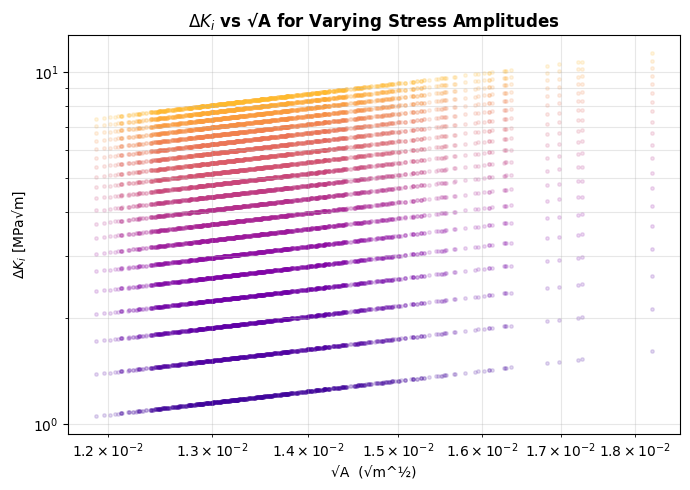

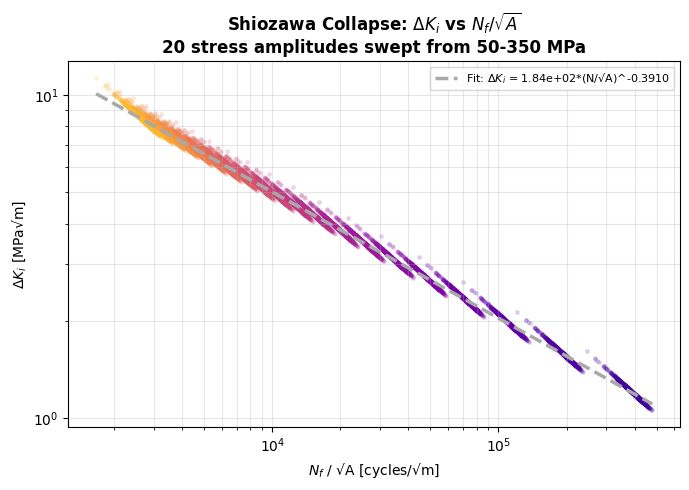

In [127]:
S_vals = np.linspace(50, 350, 20)     # stress amplitudes to sweep [MPa]

# empty lists to store info
dKi_all = []
Nnorm_all = []

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    ds_i = 2.0 * Si                       # delta_sigma for R = -1
    
    Nf_i = fatigue_life_paris(max_defects, Si, C, m, Y, delta_sigma=ds_i)
    dKi_i = delta_K_initial(max_defects, ds_i, Y)
    sqrt_A_i = np.sqrt(max_defects)

    Nnorm_i = (Nf_i / sqrt_A_i)           # normalized life, N/√A [cycles/√m]
    
    # store results
    dKi_all.append(dKi_i)
    Nnorm_all.append(Nnorm_i)

    # plots
    ax1.scatter(sqrt_A_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )
    ax2.scatter(Nnorm_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )

all_dKi = np.concatenate(dKi_all) 
all_Nnorm = np.concatenate(Nnorm_all)

log_x = np.log10(all_Nnorm)
log_y = np.log10(all_dKi)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_line = np.logspace(log_x.min(), log_x.max(), 300)
y_line = 10**intercept * x_line**slope

print(f"Shiozawa collapse fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# show fitted line from log-log fit on shiozawa collapse plot
ax2.plot(x_line, y_line, color="darkgray", linewidth=2.5, linestyle="--",
         label=f"Fit: $\\Delta K_i$ = {10**intercept:.2e}*(N/√A)^{slope:.4f}")

for ax, xlabel, title in [
    # x-axis label, title for each plot
    (ax1, "√A  (√m^½)",
     "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    (ax2, "$N_f$ / √A [cycles/√m]",
     "Shiozawa Collapse: $\\Delta K_i$ vs $N_f/\\sqrt{A}$\n"
     "20 stress amplitudes swept from 50-350 MPa"),
]:

    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles for both plots
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.grid(alpha=0.3, which="both")

ax2.legend(fontsize=8, ncol=2, #title="Stress Amplitude"
           )
# save and show
fig1.tight_layout(); fig1.savefig("graphs/2_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("graphs/2_shiozawa_collapse.png",  dpi=150)
plt.show()

Across a dense sweep of stress amplitudes, the Shiozawa collapse is visible.

## 2.8. PSN Curves
probability S-N curves

In [128]:
# probabilities of failure
pf_levels = [0.10, 0.50, 0.90]   # B10, B50, B90
labels = ["B10", "B50", "B90"]

psn_results = {label: [] for label in labels}

for S in S_vals:
    ds = 2.0 * S   # for R = -1

    # fatigue lives for all sampled max defects at this stress
    Nf_S = fatigue_life_paris(max_defects, S, C, m, Y, delta_sigma=ds)
    Nf_S = np.asarray(Nf_S, dtype=float)

    # remove invalid values if needed
    Nf_S = Nf_S[np.isfinite(Nf_S)]
    Nf_S = Nf_S[Nf_S > 0]

    # percentile lives
    for pf, label in zip(pf_levels, labels):
        psn_results[label].append(np.quantile(Nf_S, pf))

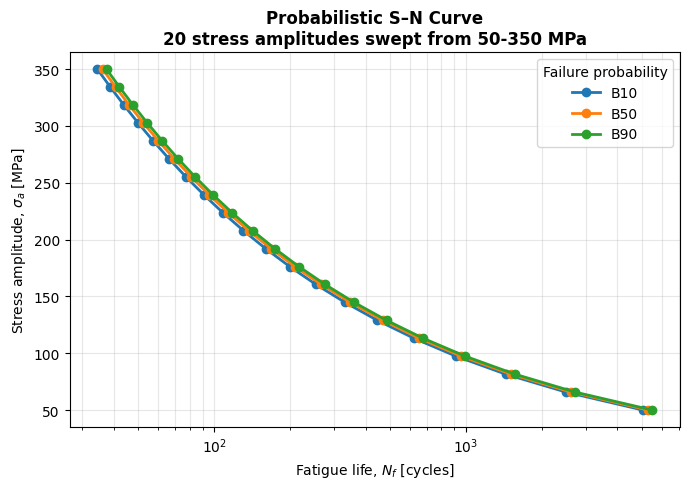

In [129]:
fig, ax = plt.subplots(figsize=(7, 5))

for label in labels:
    ax.plot(psn_results[label], S_vals,
        marker="o", linewidth=2, label=label
    )

# log scale for fatigue life
ax.set_xscale("log")

# axes labels, title, legend, grid
ax.set_xlabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Stress amplitude, $\sigma_a$ [MPa]")
ax.set_title("Probabilistic S–N Curve\n"
             "20 stress amplitudes swept from 50-350 MPa", fontweight="bold")

# legend, grid
ax.grid(True, which="both", alpha=0.3)
ax.legend(title="Failure probability")

# save and show
fig.tight_layout(); fig.savefig("graphs/2_psn.png", dpi=150)
plt.show()

# 3. PINN

In [130]:
# reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [131]:

# convert data to tensors
a_tensor = torch.tensor(max_defects_valid, dtype=torch.float32).unsqueeze(1)    # input = max defect / initial crack size
Nf_tensor = torch.tensor(Nnorm_samples_valid, dtype=torch.float32).unsqueeze(1)  # output = fatigue life

# log-transform input and output for better scaling
log_a = torch.log(a_tensor)
log_Nf = torch.log(Nf_tensor)

# normalize input defect sizes
log_a_mean = log_a.mean()
log_a_std = log_a.std()
a_scaled = (log_a - log_a_mean) / log_a_std

# normalize output cycles
log_Nf_mean = log_Nf.mean()
log_Nf_std = log_Nf.std()
N_scaled = (log_Nf - log_Nf_mean) / log_Nf_std

## 3.1. Define PINN

In [132]:
# define custom NN class
# lets PyTorch track parameters and gradients automatically
class PINN(nn.Module):
    def __init__(self): # initializes nn.Module
        super().__init__()
        self.net = nn.Sequential( # sequential container for layers, = feed-forward pipeline
            
            # first hidden layer
            nn.Linear(1, 64), # (input, output)
            nn.Tanh(),
            
            # second hidden layer
            nn.Linear(64, 64),
            nn.Tanh(),

            # output = 1 number (N), since we want to predict a single fatigue life value for each input N/√A
            nn.Linear(64, 1) 
        )

    # forward method defines how input data flows through the network
    def forward(self, N):
        log_Nf_scaled = self.net(N) # predicts scaled log(Nf)

        # convert back to physical fatigue life
        log_Nf = log_Nf_scaled * log_Nf_std + log_Nf_mean
        Nf = torch.exp(log_Nf)        # makes prediction physical and positive
        
        # predicts Nf(N)
        return Nf 

PINN Architecture from Liao et al. (2025):
- 2 hidden layers 
- 64 neurons each 
- Tanh activation function

Liao et al. (2025). A physics-informed neural network method for identifying parameters and predicting remaining life of fatigue crack growth International. Journal of Fatigue, 191, 108678. https://doi.org/10.1016/j.ijfatigue.2024.108678.

## 3.2. Define Losses

### 3.2.a. Physics Loss: Paris Law

In [133]:
# define a function to enforce the Paris Law
# everything in physics_loss must be torch operations to allow autograd to compute gradients
def physics_loss(model, a_scaled, a_physical, sigma_a, C, m, Y, delta_sigma):
    Nf_pred = model(a_scaled)

    Nf_physics = fatigue_life_paris_torch(a_physical, sigma_a, C, m, Y, delta_sigma)

    return torch.mean((Nf_pred - Nf_physics)**2)    # MSE loss
    
    # a_physical = a_physical.clone().detach().requires_grad_(True)  # ensure a is a leaf tensor for autograd

    # # scale a before feeding into the model, using the same normalization as training
    # a_scaled = (a_physical - a_mean) / a_std

    # # model prediction, a(N_scaled)
    # a = model(a_scaled)                  # NN's prediction for a(N_scaled)

    # # derivative da/dN
    # da_dN = torch.autograd.grad(
    #     a, a_physical,
    #     grad_outputs=torch.ones_like(a),    # seed vector for gradient (da/dN)
    #     create_graph=True                   # allows higher-order derivatives if needed
    # )[0]

    # stress intensity factor
    #deltaK = stress_intensity_factor_torch(delta_sigma, a_physical)

    # # Paris Law residual
    # residual = Nf_pred - Nf_physics

    # print("da_dN mean =", da_dN.abs().mean().item())
    # print("Paris mean =", (C*(deltaK**m)).abs().mean().item())

    # # ODE: da/dN + a = 0
    # return torch.mean((da_dN + a)**2)

### 3.2.b. Data Loss

In [134]:
# define a function to compute the data loss
# log-MSE between predicted and true defect sizes
def data_loss_logMSE(model, a_scaled, Nf_true):
    Nf_pred = model(a_scaled)
    return torch.mean((torch.log(Nf_pred) - torch.log(Nf_true))**2)

# MSE between predicted and true defect sizes
def data_loss_MSE(model, a_scaled, Nf_true):
    Nf_pred = model(a_scaled)
    return torch.mean((Nf_pred - Nf_true)**2)

Liao et al. (2025) uses 𝐿𝑜𝑠𝑠_𝐷 = 𝑀𝑆𝐸(𝑛_𝑝𝑟𝑒𝑑, 𝑛_𝑜𝑏𝑠) as the data loss function.

### 3.2.c. Boundary Conditions

In [135]:
# define a function to enforce initial condition, a(0)=a0
def boundary_loss(model, a0):
    N0 = torch.tensor([[0.0]], dtype=torch.float32)     # evaluate at N=0
    N0_scaled = (N0 - N_mean) / N_std
    a_pred = model(N0_scaled)                           # network's prediction at boundary pt, a(0)
    return torch.mean((torch.log(a_pred) - torch.log(torch.tensor([[a0]], dtype=torch.float32))) ** 2)

## 3.3. Training

In [142]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5000

loss_history = []
physics_loss_history = []
data_loss_history = []
#boundary_loss_history = []

# weights
w_d_liao = 100.0    # weight for data loss, from Liao et al. (2025)
w_p_liao = 1.0      # weight for physics loss, from Liao et al. (2025)
w_d = 1.0           # weight for data loss
w_p = 0.001           # weight for physics loss

# train for many iterations (epochs)
for epoch in range(epochs):
    optimizer.zero_grad()       # reset gradients before backprop

    # define losses
    loss_d = data_loss_MSE(model, a_scaled, Nf_tensor)               # enforces fit to data
    loss_p = physics_loss(model, a_scaled, a_tensor, sigma_a, C, m, Y, delta_sigma)    # enforces diff eqn everywhere
    #loss_b = boundary_loss(model, a0)                              # enforces BC at specific point(s)

    # weighted total loss
    loss = w_d * loss_d + w_p * loss_p

    loss.backward()             # backpropagation: computes gradients of all parameters
    optimizer.step()            # updates network weights

    loss_history.append(loss.item())
    physics_loss_history.append(loss_p.item())
    data_loss_history.append(loss_d.item())
    #boundary_loss_history.append(loss_b.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.item():.4e} | "
            f"Data: {loss_d.item():.4e} | "
            f"Physics: {loss_p.item():.4e} | "
            #f"BC: {loss_b.item():.4e}"
        )

Epoch     0 | Total: 3.1395e+05 | Data: 2.7393e+05 | Physics: 4.0022e+07 | 
Epoch   500 | Total: 3.9423e+04 | Data: 2.7830e+02 | Physics: 3.9145e+07 | 
Epoch  1000 | Total: 3.9221e+04 | Data: 7.8099e+01 | Physics: 3.9143e+07 | 
Epoch  1500 | Total: 3.9193e+04 | Data: 5.0775e+01 | Physics: 3.9142e+07 | 
Epoch  2000 | Total: 3.9185e+04 | Data: 4.3211e+01 | Physics: 3.9142e+07 | 
Epoch  2500 | Total: 3.9185e+04 | Data: 2.5806e+01 | Physics: 3.9159e+07 | 
Epoch  3000 | Total: 3.9182e+04 | Data: 4.0844e+01 | Physics: 3.9141e+07 | 
Epoch  3500 | Total: 3.9194e+04 | Data: 9.5816e+01 | Physics: 3.9098e+07 | 
Epoch  4000 | Total: 3.9181e+04 | Data: 3.9350e+01 | Physics: 3.9142e+07 | 
Epoch  4500 | Total: 3.9181e+04 | Data: 3.9250e+01 | Physics: 3.9142e+07 | 


*For weights (lambda_d = 100, lambda_p = 1), of first implementation*: Liao et al. (2025).

## 3.4. Predictions

In [143]:
model.eval()

with torch.no_grad():
    Nf_pred = model(a_scaled).numpy()

a_np = a_tensor.numpy()
Nf_true_np = Nf_tensor.numpy()
Nf_pred_np = Nf_pred

# sort for plotting
sort_idx = np.argsort(a_np)
a_sorted = a_np[sort_idx]
Nf_true_sorted = Nf_true_np[sort_idx]
Nf_pred_sorted = Nf_pred_np[sort_idx]

### 3.4.a. Evaluation

In [144]:
# prediction errors
errors = Nf_pred_np - Nf_true_np

mse = np.mean(errors**2)        # mean squared error
rmse = np.sqrt(mse)             # root mean squared error
mae = np.mean(np.abs(errors))   # mean absolute error

# log-space errors
log_errors = np.log(Nf_pred_np) - np.log(Nf_true_np)

log_mse  = np.mean(log_errors**2)
log_rmse = np.sqrt(log_mse)
log_mae  = np.mean(np.abs(log_errors))

# print results table
print(f"{'Metric':<10} {'Value':>14} {'Log Value':>14}")
print("-" * 42)

print(f"{'MSE':<10} {mse:>14.4e} {log_mse:>14.4e}")
print(f"{'RMSE':<10} {rmse:>14.4e} {log_rmse:>14.4e}")
print(f"{'MAE':<10} {mae:>14.4e} {log_mae:>14.4e}")

Metric              Value      Log Value
------------------------------------------
MSE            3.8218e+01     9.5148e-07
RMSE           6.1821e+00     9.7544e-04
MAE            6.1473e+00     9.7295e-04


### 3.4.b. Accuracy Plots

#### 3.4.b.i Training History Plots

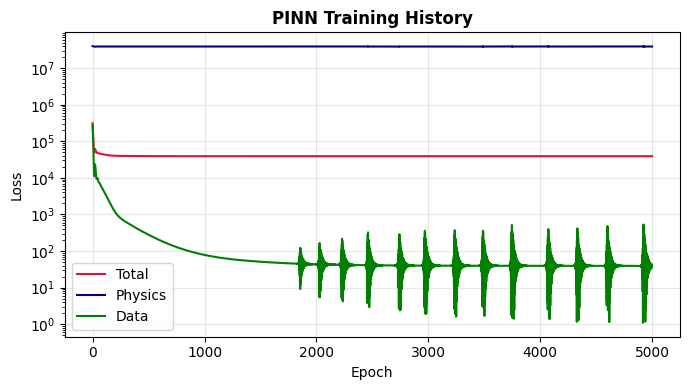

In [145]:
# plot training history
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(loss_history, color="crimson", label="Total")
ax.plot(physics_loss_history, color="navy", label="Physics")
ax.plot(data_loss_history, color="green", label="Data")
#ax.plot(boundary_loss_history, color="red", label="Boundary")

# log scale
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("PINN Training History", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("graphs/3_PINN_loss_history.png", dpi=150)
plt.show()

Observations from **PINN Training History** plot after the **first implementation** with weights from Liao et al. (2025):

- **Data loss** is decreasing smoothly over training. So, the network is fitting the training data better and better.

- **No instability**: oscillations, no exploding gradients, no null values--good news!

- **Physics loss** is basically constant. It should be decreasing. Therefore, the optimizer is prioritizing the data loss over the physics loss.
--> The weights, lambda_d = 100, lambda_p = 1, are greatly uneven.

#### 3.4.c.ii Predicted vs. True Defect Sizes

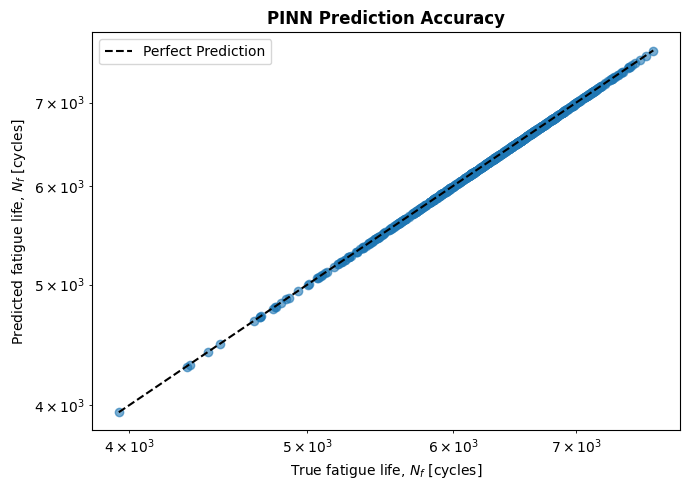

In [146]:
# plot predicted vs. true defect sizes
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_true_np, Nf_pred_np, alpha=0.6)

min_val = min(Nf_true_np.min(), Nf_pred_np.min())
max_val = max(Nf_true_np.max(), Nf_pred_np.max())

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black", label="Perfect Prediction")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel(r"True fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Predicted fatigue life, $N_f$ [cycles]")
ax.set_title("PINN Prediction Accuracy", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("graphs/3_PINN_accuracy_pred_vs_true.png", dpi=150)
plt.show()

The flattening at large crack sizes suggests the network is underpredicting the largest defects.

### 3.4.b. Crack Growth Curve

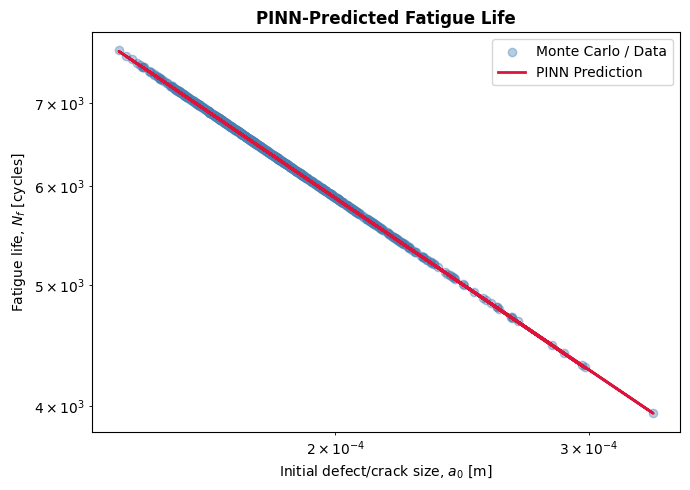

In [147]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(a_np, Nf_true_np, color="steelblue", alpha=0.4, label="Monte Carlo / Data")
ax.plot(a_np, Nf_pred_np, color="crimson", linewidth=2, label="PINN Prediction")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# labels, title
ax.set_xlabel(r"Initial defect/crack size, $a_0$ [m]")
ax.set_ylabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_title("PINN-Predicted Fatigue Life", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("graphs/3_PINN_life_vs_defect.png", dpi=150)
plt.show()

From the red **PINN Prediction curve**:
- larger defects → lower normalized life
- smaller defects → higher normalized life
→ **expected**

BUT
- PINN is too flat at low N/√A
- PINN is too steep at high N/√A 